In [ ]:
# Interband $\varepsilon_2$ of Gold — Rosei Model

Implementation of the 1D interband integrals derived in **A8** (X-point) and **A8.L** (L-point).

$$\varepsilon_2(\omega) \propto \frac{1}{\omega^2} \sum_{P} N_P \, |P_{cv}^P|^2 \int_{\mathcal{E}_{\min}^P}^{\mathcal{E}_{\max}^P} \frac{f(\mathcal{E}-\hbar\omega)\,[1-f(\mathcal{E})]}{\sqrt{g^P(\mathcal{E})}} \; d\mathcal{E}$$

| | X (saddle, A8) | L (ellipsoid, A8.L) |
|:--|:--|:--|
| Singularity | $1/\sqrt{\mathcal{E}_{\max} - \mathcal{E}}$ | $1/\sqrt{\mathcal{E} - \mathcal{E}_{\min}}$ |
| $\bar{B}$ | $B_v - B_c$ | $B_c + B_v$ |
| Multiplicity | $N_X = 6$ | $N_L = 8$ |

Band parameters: Christensen & Seraphin (1971). Matrix-element ratio $|P_X/P_L|^2 = 0.370$: Guerrisi, Rosei & Winsemius (1975).

=== X-point parameters ===
  Ac=12.29  Bc=9.53  Av=20.05  Bv=25.40
  Ābar=32.34  B̄bar=15.88  D=503.18
  Emax ratio = Ac/Ābar = 0.3800
  Emin ratio = Bc/B̄bar = 0.6000

=== L-point parameters ===
  Ac=15.88  Bc=31.75  Av=5.44  Bv=3.70
  Ābar=21.32  B̄bar=35.45  D=-114.09
  Emin ratio = Ac/Ābar = 0.7447
  Emax ratio = Bc/B̄bar = 0.8957


In [6]:
import numpy as np
from scipy.integrate import quad
import matplotlib.pyplot as plt
from dataclasses import dataclass

kB = 8.617e-5   # Boltzmann constant [eV/K]
C  = 3.81       # hbar^2 / (2 m_e)  [eV Ang^2]

def fermi(E, T):
    """Fermi-Dirac distribution; E measured from E_F."""
    if T == 0:
        return 1.0 if E < 0 else (0.5 if E == 0 else 0.0)
    return 1.0 / (1.0 + np.exp(np.clip(E / (kB * T), -500, 500)))

# ── Band parameter classes ──────────────────────────────────────────────

@dataclass
class XPointParams:
    """X-point: E_c = E0c + Ac u - Bc v  (saddle)."""
    Ac: float; Bc: float; Av: float; Bv: float
    Eg: float; E0c: float = 0.0

    def __post_init__(self):
        self.Abar = self.Ac + self.Av
        self.Bbar = self.Bv - self.Bc           # saddle sign
        self.D    = self.Ac * self.Bv + self.Av * self.Bc

    def E_max(self, hw):  return self.E0c + (self.Ac / self.Abar) * (hw - self.Eg)
    def E_min(self, hw):  return self.E0c - (self.Bc / self.Bbar) * (hw - self.Eg)
    def prefactor(self):  return 1.0 / np.sqrt(self.Abar * abs(self.D))

@dataclass
class LPointParams:
    """L-point: E_c = E0c + Ac u + Bc v  (ellipsoidal minimum)."""
    Ac: float; Bc: float; Av: float; Bv: float
    Eg: float; E0c: float = 0.0

    def __post_init__(self):
        self.Abar = self.Ac + self.Av
        self.Bbar = self.Bc + self.Bv           # both positive
        self.D    = self.Ac * self.Bv - self.Bc * self.Av

    def E_min(self, hw):  return self.E0c + (self.Ac / self.Abar) * (hw - self.Eg)
    def E_max(self, hw):  return self.E0c + (self.Bc / self.Bbar) * (hw - self.Eg)
    def prefactor(self):  return 1.0 / np.sqrt(self.Abar * abs(self.D))

# ── Gold parameters (Christensen & Seraphin 1971) ───────────────────────

X = XPointParams(Ac=C/0.31, Bc=C/0.40, Av=C/0.19, Bv=C/0.15, Eg=1.94)
L = LPointParams(Ac=C/0.24, Bc=C/0.12, Av=C/0.70, Bv=C/1.03, Eg=2.45)

N_X, N_L   = 6, 8       # valley multiplicities
P_RATIO_SQ = 0.370      # |P_X / P_L|^2

for name, p in [("X", X), ("L", L)]:
    print(f"{name}:  Ac={p.Ac:.1f}  Bc={p.Bc:.1f}  Av={p.Av:.1f}  Bv={p.Bv:.1f}"
          f"  |  Abar={p.Abar:.1f}  Bbar={p.Bbar:.1f}  D={p.D:.1f}")

X:  Ac=12.3  Bc=9.5  Av=20.1  Bv=25.4  |  Abar=32.3  Bbar=15.9  D=503.2
L:  Ac=15.9  Bc=31.8  Av=5.4  Bv=3.7  |  Abar=21.3  Bbar=35.4  D=-114.1


## Core Integrals

Both integrals have an integrable $\sqrt{}$ singularity, removed by substitution before quadrature:

**X-point** — singularity at $\mathcal{E}_{\max}$ ($t = \sqrt{\mathcal{E}_{\max} - \mathcal{E}}$):
$$\int \frac{F(\mathcal{E})\,d\mathcal{E}}{\sqrt{\mathcal{E}_{\max}-\mathcal{E}}} \;\longrightarrow\; \int_0^{t_{\max}} 2\,F(\mathcal{E}_{\max}-t^2)\,dt$$

**L-point** — singularity at $\mathcal{E}_{\min}$ ($t = \sqrt{\mathcal{E} - \mathcal{E}_{\min}}$):
$$\int \frac{F(\mathcal{E})\,d\mathcal{E}}{\sqrt{\mathcal{E}-\mathcal{E}_{\min}}} \;\longrightarrow\; \int_0^{t_{\max}} 2\,F(\mathcal{E}_{\min}+t^2)\,dt$$

For **absorption**: $F = f(\mathcal{E}-\hbar\omega)\,[1-f(\mathcal{E})]$. For **emission**: $F = f(\mathcal{E})\,[1-f(\mathcal{E}-\hbar\omega)]$.

In [7]:
def _F_abs(E, hw, T):
    """Absorption: f(E-hw) [1-f(E)]."""
    return fermi(E - hw, T) * (1.0 - fermi(E, T))

def _F_emi(E, hw, T):
    """Emission: f(E) [1-f(E-hw)]."""
    return fermi(E, T) * (1.0 - fermi(E - hw, T))

def _interband_integral(hw, T, p, F, is_L=False):
    """Regularised 1D interband integral for a given Fermi factor F."""
    if hw <= p.Eg:
        return 0.0
    e_min, e_max = p.E_min(hw), p.E_max(hw)
    if e_max <= e_min:
        return 0.0
    t_max = np.sqrt(e_max - e_min)
    if is_L:
        integrand = lambda t: 2.0 * F(e_min + t**2, hw, T)
    else:
        integrand = lambda t: 2.0 * F(e_max - t**2, hw, T)
    result, _ = quad(integrand, 0, t_max)
    return p.prefactor() * result

def eps2_total(hw, T, mode="abs"):
    """Total interband eps2 ~ (1/w^2) sum_P N_P |P|^2 I_P.
    mode: 'abs' for absorption, 'emi' for emission."""
    F = _F_abs if mode == "abs" else _F_emi
    I_X = N_X * P_RATIO_SQ * _interband_integral(hw, T, X, F, is_L=False)
    I_L = N_L              * _interband_integral(hw, T, L, F, is_L=True)
    return (I_X + I_L) / hw**2, I_X / hw**2, I_L / hw**2

# Sanity check
tot, cx, cl = eps2_total(2.6, 300.0)
print(f"eps2(2.6 eV, 300 K):  X={cx:.3e}  L={cl:.3e}  Total={tot:.3e}")

eps2(2.6 eV, 300 K):  X=2.566e-03  L=7.149e-03  Total=9.716e-03


## Interband Absorption Spectrum

Decomposition into X-point ($\mathcal{E}_g^X = 1.94$ eV, saddle onset) and L-point ($\mathcal{E}_g^L = 2.45$ eV, Fermi edge) contributions at room temperature.

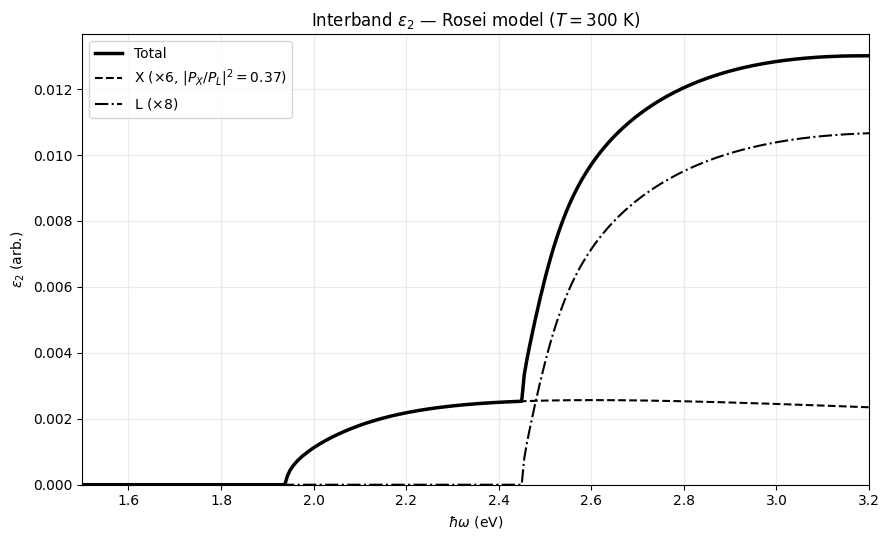

In [8]:
T = 300.0
energies = np.linspace(1.5, 3.2, 300)
eps_tot, eps_X, eps_L = np.array([eps2_total(hw, T) for hw in energies]).T

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(energies, eps_tot, 'k-',  lw=2.5, label='Total')
ax.plot(energies, eps_X,   'k--', lw=1.5, label=f'X ($\\times{N_X}$, $|P_X/P_L|^2={P_RATIO_SQ}$)')
ax.plot(energies, eps_L,   'k-.', lw=1.5, label=f'L ($\\times{N_L}$)')
ax.set(xlabel=r'$\hbar\omega$ (eV)', ylabel=r'$\varepsilon_2$ (arb.)',
       xlim=(1.5, 3.2), ylim=(0, None))
ax.set_title(f'Interband $\\varepsilon_2$ — Rosei model ($T={T:.0f}$ K)')
ax.legend(); ax.grid(alpha=0.25)
fig.tight_layout()

## Temperature Dependence

At $T = 0$ the Fermi factors produce a sharp step at threshold. Increasing $T$ smears the onset by ${\sim}4k_BT$ and opens a sub-gap tail through thermally occupied states. Comparing $T = 10, 300, 600$ K shows the effect is most visible near the X-point edge.

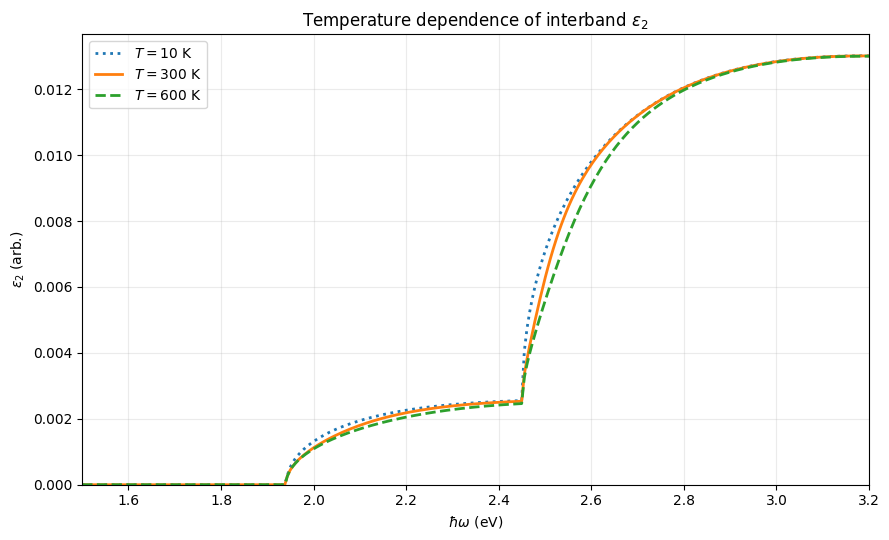

In [9]:
fig, ax = plt.subplots(figsize=(9, 5.5))
for T_i, ls in [(10, ':'), (300, '-'), (600, '--')]:
    eps = np.array([eps2_total(hw, T_i)[0] for hw in energies])
    ax.plot(energies, eps, ls, lw=2, label=f'$T={T_i}$ K')
ax.set(xlabel=r'$\hbar\omega$ (eV)', ylabel=r'$\varepsilon_2$ (arb.)',
       xlim=(1.5, 3.2), ylim=(0, None))
ax.set_title('Temperature dependence of interband $\\varepsilon_2$')
ax.legend(); ax.grid(alpha=0.25)
fig.tight_layout()

## Kirchhoff / Detailed Balance Check

At thermal equilibrium the emission-to-absorption ratio must obey

$$\frac{\varepsilon_2^{\text{emi}}(\omega)}{\varepsilon_2^{\text{abs}}(\omega)} = e^{-\hbar\omega / k_BT}$$

i.e., the Fermi factor identity $f(E)[1-f(E-\hbar\omega)] = e^{-\beta\hbar\omega}\,f(E-\hbar\omega)[1-f(E)]$. This provides a stringent numerical consistency check on the implementation.

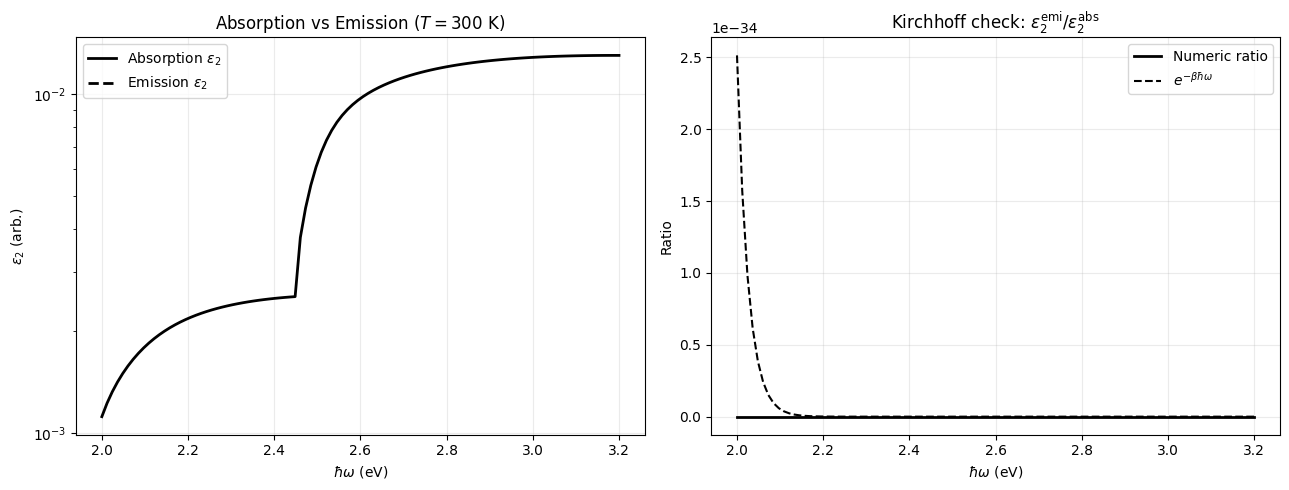

In [10]:
T = 300.0
test_hw = np.linspace(2.0, 3.2, 100)

abs_vals = np.array([eps2_total(hw, T, "abs")[0] for hw in test_hw])
emi_vals = np.array([eps2_total(hw, T, "emi")[0] for hw in test_hw])
boltz    = np.exp(-test_hw / (kB * T))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: absorption vs emission
ax = axes[0]
ax.semilogy(test_hw, abs_vals, 'k-',  lw=2, label='Absorption $\\varepsilon_2$')
ax.semilogy(test_hw, emi_vals, 'k--', lw=2, label='Emission $\\varepsilon_2$')
ax.set(xlabel=r'$\hbar\omega$ (eV)', ylabel=r'$\varepsilon_2$ (arb.)')
ax.set_title(f'Absorption vs Emission ($T={T:.0f}$ K)')
ax.legend(); ax.grid(alpha=0.25)

# Right: ratio check
ax = axes[1]
mask = abs_vals > 1e-30
ratio = np.where(mask, emi_vals / abs_vals, np.nan)
ax.plot(test_hw, ratio, 'k-', lw=2, label='Numeric ratio')
ax.plot(test_hw, boltz, 'k--', lw=1.5, label=r'$e^{-\beta\hbar\omega}$')
ax.set(xlabel=r'$\hbar\omega$ (eV)', ylabel='Ratio')
ax.set_title('Kirchhoff check: $\\varepsilon_2^{\\mathrm{emi}} / \\varepsilon_2^{\\mathrm{abs}}$')
ax.legend(); ax.grid(alpha=0.25)

fig.tight_layout()